In [ ]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
embeddings = GoogleGenerativeAIEmbeddings(model="models/embedding-001")

: 

In [4]:
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"  # small & fast
)

In [23]:
from langchain_groq import ChatGroq
import os
llm=ChatGroq(model_name="llama-3.1-8b-instant")
llm.invoke("hi").content

'How can I assist you today?'

In [1]:

from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_community.document_loaders import TextLoader, DirectoryLoader
from langchain_chroma import Chroma                                    # ✅ updated import
from langchain_text_splitters import RecursiveCharacterTextSplitter    # ✅ updated import

f:\Conda\envs\langgraph_tut_venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
loader=DirectoryLoader("../data",glob="./*.txt",loader_cls=TextLoader)
docs=loader.load()
text_splitter=RecursiveCharacterTextSplitter(
    chunk_size=100,
    chunk_overlap=50
)
new_docs = text_splitter.split_documents(documents=docs)
doc_strings = [doc.page_content for doc in new_docs]

In [5]:
db = Chroma.from_documents(new_docs, embeddings)

retriever = db.as_retriever(search_kwargs={"k": 3})

In [7]:
query = "what is meta llama3?"
docs = retriever.invoke(query)
print(docs[0].metadata)
print(docs[0].page_content)



{'source': '..\\data\\llama3.txt'}
by Meta AI starting in February 2023.[2][3] The latest version is Llama 3 released in April


In [8]:
for doc in docs:
    print(doc)

page_content='by Meta AI starting in February 2023.[2][3] The latest version is Llama 3 released in April' metadata={'source': '..\\data\\llama3.txt'}
page_content='services use a Llama 3 model.[12] Reception was mixed, with some users confused after Meta AI told' metadata={'source': '..\\data\\llama3.txt'}
page_content='available as a foundation model.[8] Starting with Llama 2, Meta AI started releasing instruction' metadata={'source': '..\\data\\llama3.txt'}


In [29]:
def function_1(AgentState):
    
    message=AgentState["messages"]
    
    question=message[-1]
    
    complete_prompt="Your task is to provide only the brief answer based on the user query. \
        Don't include too much reasoning. Following is the user query: " + question
    
    response = llm.invoke(complete_prompt)
    
    AgentState['messages'].append(response.content) # appending LLM call response to the AgentState
    
    #print(AgentState)
    
    return AgentState

In [10]:

AgentState={}

In [11]:
AgentState["messages"] = []

In [12]:
AgentState

{'messages': []}

In [13]:
AgentState["messages"].append("hi, how are you?")

In [14]:

AgentState

{'messages': ['hi, how are you?']}

In [15]:

AgentState["messages"].append("hi, what you doing?")

In [16]:

AgentState

{'messages': ['hi, how are you?', 'hi, what you doing?']}

In [28]:
def function_2(AgentState):
    messages = AgentState['messages']
    question = messages[0]  # Fetching the user question

    template = """Answer the question based only on the following context:
    {context}

    Question: {question}
    """
    prompt = ChatPromptTemplate.from_template(template)

    retrieval_chain = (
        {"context": retriever, "question": RunnablePassthrough()}
        | prompt
        | llm
        | StrOutputParser()
    )
    result = retrieval_chain.invoke(question)
    return {"messages": messages + [result]}  # ✅ return state dict

In [30]:
# Define a Langgraph graph
from langgraph.graph import StateGraph, END
from typing import TypedDict

class AgentState(TypedDict):
    messages: list

workflow4 = StateGraph(AgentState)
workflow4.add_node("LLM", function_1)
workflow4.add_node("RAGtool", function_2)
workflow4.add_edge("LLM", "RAGtool")
workflow4.add_edge("RAGtool", END)
workflow4.set_entry_point("LLM")

app4 = workflow4.compile()

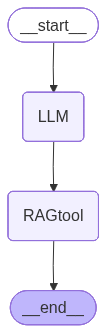

In [20]:
from IPython.display import Image, display

try:
    display(Image(app4.get_graph().draw_mermaid_png()))
except Exception as e:
    # This requires some extra dependencies and is optional
    print(e)

In [21]:
inputs = {"messages": ["Tell me about llama3 model"]}

In [31]:
inputs = {"messages": ["what is meta llama3?"]}

for output in app4.stream(inputs):
    for key, value in output.items():
        print(f"Output from node '{key}':")
        print("---")
        print(value)
    print("\n---\n")

Output from node 'LLM':
---
{'messages': ['what is meta llama3?', 'Meta Llama 3 is a large language model developed by Meta.']}

---

Output from node 'RAGtool':
---
{'messages': ['what is meta llama3?', 'Meta Llama 3 is a large language model developed by Meta.', 'Based on the provided context, Meta Llama 3, also known as Llama 3, is a model released in February 2023 and further updated in April.']}

---

